In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
print(train_data.shape)
print(train_data.head())
print(train_data.info())
print(train_data.describe())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [5]:
print(train_data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print("Overall survival rate:", train_data['Survived'].mean())

Overall survival rate: 0.3838383838383838


In [7]:
women = train_data.loc[train_data.Sex=="female"]["Survived"]
rate_women = sum(women)/len(women)
print("The Rate of Female Passengers survived on The Titanic:", rate_women)

The Rate of Female Passengers survived on The Titanic: 0.7420382165605095


In [8]:
men = train_data.loc[train_data.Sex=="male"]["Survived"]
rate_men = sum(men)/len(men)
print("The Rate of Male Passengers survived on The Titanic:", rate_men)

The Rate of Male Passengers survived on The Titanic: 0.18890814558058924


In [9]:
print(train_data.groupby('Pclass')['Survived'].mean())


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


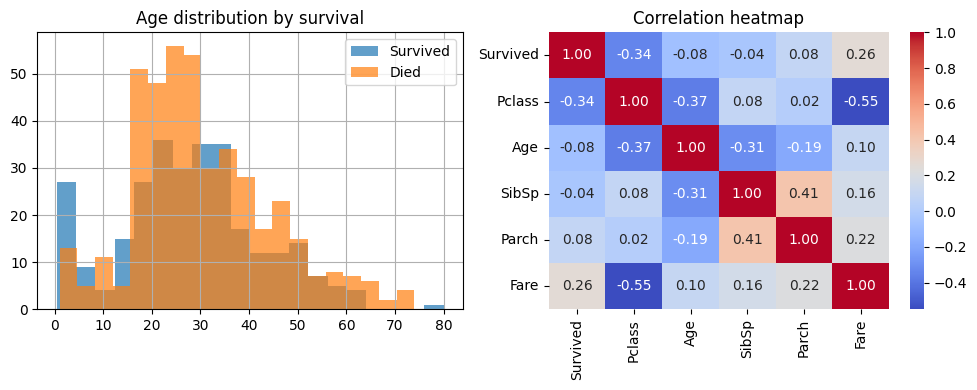

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
train_data[train_data['Survived']==1]['Age'].hist(bins=20, alpha=0.7, label='Survived')
train_data[train_data['Survived']==0]['Age'].hist(bins=20, alpha=0.7, label='Died')
plt.legend()
plt.title('Age distribution by survival')

plt.subplot(1, 2, 2)
sns.heatmap(train_data[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

By looking at the graph plotted using matplotlib in python which is telling the dead to survival ratio by age.
We can see that:
1. More babies of age less than 1 survived than died.
2. The chances of surviving is more of children of age less than 15. But there is a catch in this which is making this approach wrong as more children of age 10 died than survived.
3. The highest deaths are from the age group 15-30 and people of age 30-35. The deaths are higher than survival from the age group higher than 35.
4. Nobody survived of the age group 65-75 but all(maybe 1) survived of age group 75-80.

In [11]:
test_data = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [12]:
# Combine train and test to process together
combined = [train_data, test_data]

for df in combined:
    # 1. Sex → number
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    # 2. Fill missing Age with median
    df['AgeBand'] = pd.cut(df['Age'].fillna(df['Age'].median()),
                           bins=[0, 12, 18, 35, 60, 100],
                           labels=[0, 1, 2, 3, 4]).astype(int)

    # 3. Fill missing Embarked with most common
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode().iloc[0])

    # 4. Fill missing Fare with median
    df['FareBand'] = pd.qcut(df['Fare'].fillna(df['Fare'].median()),
                             q=4,
                             labels=[0, 1, 2, 3],
                             duplicates='drop').astype(int)

    # 5. New feature: Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # 6. New feature: Is the person alone?
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # 7. Extract title from name (Mr, Mrs, Miss etc.)
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
    df['Title'] = df['Title'].map({'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4})
    df['Title'].fillna(0)

    # 8. Encode Embarked
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Drop columns we don't need
drop_cols = ['Name', 'Ticket', 'Cabin', 'PassengerId']
train_data_clean = train_data.drop(columns=drop_cols)
test_data_clean  = test_data.drop(columns=[c for c in drop_cols if c in test_data.columns])

print(train_data_clean.head())
print(train_data_clean.isnull().sum()) # should be all zeros


print(train_data[['Age','AgeBand','Fare','FareBand']].head(10))
print("\nAny nulls?", train_data[['AgeBand','FareBand']].isnull().sum().sum())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  AgeBand  \
0         0       3    0  22.0      1      0   7.2500         0        2   
1         1       1    1  38.0      1      0  71.2833         1        3   
2         1       3    1  26.0      0      0   7.9250         0        2   
3         1       1    1  35.0      1      0  53.1000         0        2   
4         0       3    0  35.0      0      0   8.0500         0        2   

   FareBand  FamilySize  IsAlone  Title  
0         0           2        0      0  
1         3           2        0      2  
2         1           1        1      1  
3         3           2        0      2  
4         1           1        1      0  
Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked        0
AgeBand         0
FareBand        0
FamilySize      0
IsAlone         0
Title           0
dtype: int64
    Age  AgeBand     Fare  FareBand
0  22.0 

In [13]:
drop_features = ['SibSp', 'Parch', 'IsAlone']

X = train_data_clean.drop(['Survived'] + drop_features, axis=1)
y = train_data_clean['Survived']

X_test_data = test_data_clean.drop(drop_features, axis=1, errors='ignore')

# Verify
print("Features kept:", X.columns.tolist())

Features kept: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'AgeBand', 'FareBand', 'FamilySize', 'Title']


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV


X = train_data_clean.drop('Survived', axis=1)
y = train_data_clean['Survived']


# lr = LogisticRegression(max_iter=200)
# lr_scores = cross_val_score(lr, X, y, cv=5)
# print(f"Logistic Regression: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X, y, cv=5)
print(f"Random Forest: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")


params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Random Forest: 0.810 ± 0.029
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best CV score: 0.8316364321134895


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Features — same for both
FEATURES = ['Pclass', 'Sex', 'Age', 'Fare',
            'Embarked', 'Title', 'FamilySize',
            'AgeBand', 'FareBand']

X      = train_data_clean[FEATURES]
y      = train_data_clean['Survived']
X_test_data = test_data_clean[FEATURES]

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Predict
predictions = model.predict(X_test_data)

# Save
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived':    predictions
})

submission.to_csv('submission.csv', index=False)
print("Done! submission.csv is ready.")
print(submission['Survived'].value_counts())

Done! submission.csv is ready.
Survived
0    260
1    158
Name: count, dtype: int64
